The same logic as 5_leakage_lr.ipynb, but using xgboost instead of logistic regression

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

from sklearn.metrics import f1_score, roc_auc_score
import shap

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Same configurations

In [2]:
BINARY_PFS = True
RNA_SEQ_ONLY = True

pfs_dir = "binary" if BINARY_PFS else "three-classes"
rna_suffix = "_rna" if RNA_SEQ_ONLY else ""

In [3]:
# Load gex_mat_corrected
gex_mat = pd.read_csv(f"../dataset/created/{pfs_dir}/gex_mat_corrected{rna_suffix}.csv").set_index('sample_id').T
gex_mat['sample_id'] = gex_mat.index

# print(gex_mat.shape)
# gex_mat.head()

In [4]:
# Load clinical_gex
clinical_gex = pd.read_csv(f"../dataset/created/{pfs_dir}/clinical_gex{rna_suffix}.csv", low_memory=False)

# print(clinical_gex.shape)
# clinical_gex.head()

Grouping features based on type

In [5]:
# Clinical feature groups
clinical_ordinal_col    = ['M_stage']
clinical_categorical_cols = ['sex', 'AJCC_stage', 'LDH', 'immunotherapy_treatment', 'pre_MAPKi_treatment']
clinical_numeric_col    = ['age']
clinical_drug_braf_cols = ['cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
                           'C195W', 'K601I', 'MND', 'V600E', 'V600K', 'V600R'] 
clinical_remaining_cols = ['patientID', 'sample_id', 'pfs_label', 'source']

# sometime certain drugs or gene are missing in the dataset
clinical_drug_braf_cols = [c for c in clinical_drug_braf_cols if c in clinical_gex.columns]

CLINICAL_COLS = (clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col
                + clinical_drug_braf_cols + clinical_remaining_cols)

GEX_COLS_ORI = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]

print('Original clinical_gex features:')
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_ORI)} = {len(CLINICAL_COLS)+len(GEX_COLS_ORI)}')

Original clinical_gex features:
clinical + gex = 18 + 51465 = 51483


Load the batch corrected gex matrix, replace the genes in clinical+gex dataset with corrected one

In [6]:
# Merge into clinical_gex_corrected
clinical_gex_filtered = clinical_gex[CLINICAL_COLS]
clinical_gex_filtered

clinical_gex_filtered = clinical_gex_filtered.merge(gex_mat, on='sample_id', how='inner')
print(clinical_gex_filtered.shape)
clinical_gex_filtered.head()

(78, 23404)


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.671622,3.097789,0.556946,1.192834,2.773766,0.052665,2.079754,6.546661,2.954971,2.939248
1,M1A,female,IV,normal,no,no,58,0,0,0,...,2.973160,3.505208,0.697100,1.042928,2.612191,-0.003464,2.432721,5.618133,2.969150,2.586618
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.652098,2.859687,0.707183,1.066919,2.500457,0.260227,2.217228,6.528220,3.161277,3.463558
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,2.360416,2.718169,0.797301,1.066046,2.408641,-0.027371,2.047882,6.690812,3.135011,2.232254
4,M1C,male,IV,normal,no,no,33,1,0,0,...,3.004662,1.821515,0.810193,1.336957,2.891467,-0.052370,2.847988,5.547082,3.319700,3.505455


In [7]:
GEX_COLS_FILTERED = [c for c in clinical_gex_filtered.columns if c not in CLINICAL_COLS]

# print('Filtered clinical_gex features:')
# print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_FILTERED)} = {len(CLINICAL_COLS)+len(GEX_COLS_FILTERED)}')

Feature selection on gex columns

In [8]:
clinical_gex_filtered.columns = clinical_gex_filtered.columns.str.strip()
y = clinical_gex_filtered['pfs_label']

pre_selection_pipe = Pipeline([
    ('threshold', VarianceThreshold(threshold=0.1)),
    ('seleckbest', SelectKBest(f_classif, k=20)),
])

gex_cols_selected = clinical_gex_filtered[GEX_COLS_FILTERED]
gex_cols_selected = pre_selection_pipe.fit_transform(gex_cols_selected, y)
gex_cols_selected = pre_selection_pipe.get_feature_names_out()
gex_cols_selected

array(['ADAM9', 'ALDH5A1', 'CLN8', 'CXCR5', 'DOCK1', 'FANCC', 'LATS2',
       'MIR23B', 'NME7', 'NOTCH1', 'PGM3', 'POU5F1B', 'PTPDC1', 'PYROXD2',
       'REEP4', 'SLC25A26', 'SLC36A1', 'STX2', 'TBC1D1', 'TTYH3'],
      dtype=object)

In [9]:
if y.nunique() == 2:
    BINARY_PFS = True
elif y.nunique() == 3:
    BINARY_PFS = False
else:
    raise ValueError('NOT BINARY NOR 3 CLASSES!!')

Split train & test set

In [10]:
from sklearn.model_selection import train_test_split

x = clinical_gex_filtered[clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col
                + clinical_drug_braf_cols + list(gex_cols_selected)]
print(f'Dropped {len(clinical_remaining_cols)} clinical cols, {x.shape} remaining')
x.head()

Dropped 4 clinical cols, (78, 34) remaining


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,PGM3,POU5F1B,PTPDC1,PYROXD2,REEP4,SLC25A26,SLC36A1,STX2,TBC1D1,TTYH3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.443080,2.141003,0.931685,4.234438,3.985531,2.862709,1.772129,2.662525,3.450505,5.766345
1,M1A,female,IV,normal,no,no,58,0,0,0,...,2.794743,1.864743,2.177455,5.487388,3.977597,3.950642,2.153561,2.604217,4.169673,5.042936
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.386117,0.287365,1.967457,3.696172,3.419210,3.310499,1.903797,3.082058,4.176691,4.231001
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,3.407065,-0.018395,1.793883,1.790559,4.214246,2.521257,2.667367,2.773497,3.657964,5.446579
4,M1C,male,IV,normal,no,no,33,1,0,0,...,2.434724,0.557978,2.212628,3.349597,4.669941,3.205905,1.680879,2.705381,3.115369,5.659641


In [11]:
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")


Target distribution:
pfs_label
0    47
1    31
Name: count, dtype: int64


Preprocessing Pipeline

In [12]:
preprocess_features = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan,
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='if_binary')),
        ]), clinical_categorical_cols),

        ('age',      SimpleImputer(strategy='median'), clinical_numeric_col),
        ('drug_braf', 'passthrough',                   clinical_drug_braf_cols),
    ],
    remainder='passthrough',    # gene expressions
)

# Test only GEX features
# preprocess_features = ColumnTransformer(
#     transformers=[
#         ('gex', 'passthrough', list(gex_cols_selected)),
#     ],
#     remainder='drop',
# )

Full pipeline

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if BINARY_PFS:
    clf = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
    )
else:
    clf = XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
    )

full_pipe = Pipeline([
    ('preprocess', preprocess_features),
    ('clf', clf)
])

Tune hyperparams

In [14]:
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 1, 4),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
    }
    clf.set_params(**params)

    if BINARY_PFS == True:
        scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1', n_jobs=-1)
    else:
        scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1_macro', n_jobs=-1)

    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=300)

print(study.best_params)
print(f"Best CV F1 (or macro F1 if 3 classes): {study.best_value:.3f}")

[I 2026-07-21 17:43:04,635] A new study created in memory with name: no-name-a4c677f3-9e4b-4321-8ee6-11dd157e6810
[I 2026-07-21 17:43:06,967] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.40921304830970556, 'reg_alpha': 0.004207053950287938, 'reg_lambda': 0.0017073967431528124, 'min_child_weight': 9, 'gamma': 1.2022300234864176}. Best is trial 0 with value: 0.0.
[I 2026-07-21 17:43:08,390] Trial 1 finished with value: 0.7652214452214452 and parameters: {'n_estimators': 383, 'max_depth': 1, 'learning_rate': 0.27081608642499677, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.44863737747479326, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254, 'min_child_weight': 4, 'gamma': 1.0495128632644757}. Best is trial 1 with value: 0.7652214452214452.
[I 2026-07-21 17:43:08,456] Trial 2 finished with value: 0.0 and parameters: {'n_estimato

{'n_estimators': 435, 'max_depth': 3, 'learning_rate': 0.017280194323004983, 'subsample': 0.5003873519245522, 'colsample_bytree': 0.7100970969119699, 'reg_alpha': 0.033551089017531864, 'reg_lambda': 0.014338527438633892, 'min_child_weight': 1, 'gamma': 1.9583901221257562}
Best CV F1 (or macro F1 if 3 classes): 0.834


Train and evaluate with sklearn's cross_validate

Train ROC-AUC : 1.000 ± 0.000
Train  F1     : 0.976 ± 0.015
Test ROC-AUC  : 0.911 ± 0.059
Test F1       : 0.834 ± 0.068

              precision    recall  f1-score   support

  Short resp       0.88      0.91      0.90        47
   Long resp       0.86      0.81      0.83        31

    accuracy                           0.87        78
   macro avg       0.87      0.86      0.86        78
weighted avg       0.87      0.87      0.87        78



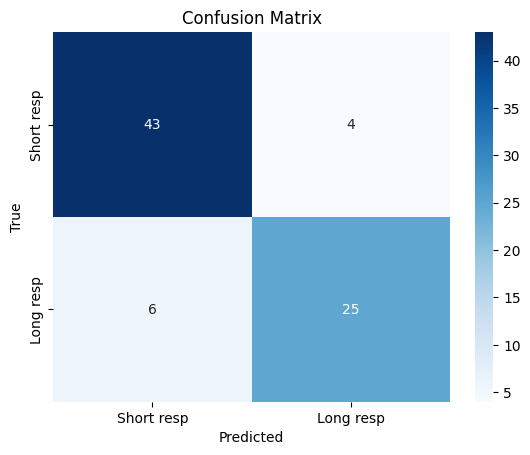

In [15]:
full_pipe.set_params(**{f'clf__{k}': v for k, v in study.best_params.items()})

if BINARY_PFS == True:
    results = cross_validate(
        full_pipe, x, y,
        cv=skf,
        scoring=['roc_auc', 'f1'],
        return_train_score=True,
        n_jobs=-1,
        return_estimator=True
    )
    
    print(f"Train ROC-AUC : {results['train_roc_auc'].mean():.3f} ± {results['train_roc_auc'].std():.3f}")
    print(f"Train  F1     : {results['train_f1'].mean():.3f} ± {results['train_f1'].std():.3f}")
    print(f"Test ROC-AUC  : {results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}")
    print(f"Test F1       : {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}\n")
    
    target_names = ['Short resp', 'Long resp']
else:
    results = cross_validate(
        full_pipe, x, y,
        cv=skf,
        scoring=['roc_auc_ovo', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1,
        return_estimator=True
    )
    
    print(f"Train ROC-AUC (OVO): {results['train_roc_auc_ovo'].mean():.3f} ± {results['train_roc_auc_ovo'].std():.3f}")
    print(f"Train Macro F1     : {results['train_f1_macro'].mean():.3f} ± {results['train_f1_macro'].std():.3f}")
    print(f"Test ROC-AUC (OVO) : {results['test_roc_auc_ovo'].mean():.3f} ± {results['test_roc_auc_ovo'].std():.3f}")
    print(f"Test Macro F1      : {results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}\n")
    
    target_names = ['Short resp', 'Intermediate', 'Long resp']

y_pred = cross_val_predict(
    full_pipe, x, y,
    cv=skf,
    n_jobs=-1
)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Check how many genes overlap between folds

In [16]:
selected_per_fold = []
for tr, _ in skf.split(x, y):
    full_pipe.fit(x.iloc[tr], y.iloc[tr])
    names = full_pipe['preprocess'].get_feature_names_out()
    importances = full_pipe['clf'].feature_importances_
    mask = importances > 0
    selected_per_fold.append(set(names[mask]))

gex_per_fold = [{f for f in fold if f.startswith('remainder__')} for fold in selected_per_fold]

common_gex = set.intersection(*gex_per_fold)
union_gex  = set.union(*gex_per_fold)
sizes_gex  = [len(s) for s in gex_per_fold]

print(f"GEX per-fold sizes : {sizes_gex}")
print(f"GEX in all folds   : {len(common_gex)} → {common_gex}")
print(f"GEX union size     : {len(union_gex)}")
print(f"GEX stability ratio: {len(common_gex) / max(1, min(sizes_gex)):.2f}")

GEX per-fold sizes : [20, 20, 20, 20, 20]
GEX in all folds   : 20 → {'remainder__DOCK1', 'remainder__NME7', 'remainder__SLC25A26', 'remainder__LATS2', 'remainder__FANCC', 'remainder__MIR23B', 'remainder__TTYH3', 'remainder__ALDH5A1', 'remainder__CXCR5', 'remainder__POU5F1B', 'remainder__CLN8', 'remainder__PTPDC1', 'remainder__ADAM9', 'remainder__TBC1D1', 'remainder__PGM3', 'remainder__STX2', 'remainder__PYROXD2', 'remainder__SLC36A1', 'remainder__NOTCH1', 'remainder__REEP4'}
GEX union size     : 20
GEX stability ratio: 1.00


Check genes overlap with KEGG-VCELLS genes

In [17]:
with open("../dataset/additional/combine-kegg-vcells.txt") as f:
    kegg_vcells = {g.strip() for g in f.read().split(",")}

GEX_COLS_KEGG = [g for g in common_gex if g in kegg_vcells]

print(f"combine-kegg-vcells genes : {len(kegg_vcells)}")
print(f"GEX_COLS_FILTERED genes   : {len(common_gex)}")
print(f"Overlap (GEX_COLS_KEGG)   : {len(GEX_COLS_KEGG)}")

combine-kegg-vcells genes : 174
GEX_COLS_FILTERED genes   : 20
Overlap (GEX_COLS_KEGG)   : 0


Save best model (across different train-test splits) for explanability

In [18]:
print(results['test_roc_auc'])
print(results['test_f1'])

[0.8        0.93333333 0.95238095 0.96296296 0.90740741]
[0.76923077 0.8        0.76923077 0.90909091 0.92307692]


In [19]:
# import joblib
# import os

# fold_idx = 4    # choose fold 4 model

# best_pipeline = results["estimator"][fold_idx] 

# os.makedirs(f"../saved-models/{pfs_dir}", exist_ok=True)
# joblib.dump(best_pipeline, f'../saved-models/{pfs_dir}/best_pipeline{rna_suffix}_xgboost.joblib')

In [20]:
splits = list(skf.split(x, y))
train_idx, test_idx = splits[fold_idx]   

x_train = x.iloc[train_idx]
x_test  = x.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

# x_train.to_csv(f"../dataset/created/{pfs_dir}/x_train{rna_suffix}_xgboost.csv", index=False)
# x_test.to_csv(f"../dataset/created/{pfs_dir}/x_test{rna_suffix}_xgboost.csv", index=False)
# y_train.to_csv(f"../dataset/created/{pfs_dir}/y_train{rna_suffix}_xgboost.csv", index=False)
# y_test.to_csv(f"../dataset/created/{pfs_dir}/y_test{rna_suffix}_xgboost.csv", index=False)

NameError: name 'fold_idx' is not defined